# RAG-Stress — Qwen3.5-9B L4 Full Inference + Evaluation

This notebook runs the complete final benchmark with:

```text
Qwen/Qwen3.5-9B
```

on an **NVIDIA L4** using **BF16 with no quantization**.

It uses the four final datasets:

```text
clean_500.jsonl
distractor_D1_D3_D5_500.jsonl
position_begin_middle_end_500.jsonl
counterfactual_strict_semantic.jsonl   # Counterfactual V2
```

The notebook performs the entire pipeline:

```text
load datasets
    ↓
load Qwen3.5-9B
    ↓
resumable inference
    ↓
save raw answers to Google Drive
    ↓
EM / Token F1 evaluation
    ↓
D1 / D3 / D5 degradation
    ↓
Beginning / Middle / End analysis
    ↓
Counterfactual V2 CFR / GFR / OTHER
    ↓
by-type and by-source counterfactual analysis
    ↓
save evaluated JSONLs, CSVs, JSON summary and figures to Drive
```

All 9B outputs are isolated from the previous Qwen3-4B experiment.


## 1. Install dependencies

In [1]:
# Qwen3.5 requires a recent Transformers build.
!pip -q install -U transformers accelerate sentencepiece tqdm pandas matplotlib scipy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.4/57.4 kB 5.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 8.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 8.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.4/62.4 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 123.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.2/80.2 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 138.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 136.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.3/35.3 MB 72.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.3, but you have pandas 3.0.6 which is incompatible.
cudf-cu13 26.6.0 r

## 2. Imports and Google Drive

In [1]:
from pathlib import Path
import json
import re
import string
import gc
import shutil
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from tqdm.auto import tqdm

from google.colab import drive

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 3. Configuration

In [2]:
MODEL_NAME = "Qwen/Qwen3.5-9B"
MODEL_TAG = "qwen35_9b"

# L4 supports BF16. No 4-bit / 8-bit quantization is used.
MODEL_DTYPE = torch.bfloat16

# Actual benchmark contexts are far below this limit,
# but this leaves comfortable headroom.
MAX_INPUT_TOKENS = 4096
MAX_NEW_TOKENS = 32

# Start at 2 on L4. The inference function automatically
# falls back to batch size 1 if CUDA OOM occurs.
INFERENCE_BATCH_SIZE = 2

SEED = 42

torch.manual_seed(SEED)

# ---------------------------------------------------------
# Google Drive directories
# ---------------------------------------------------------
DRIVE_ROOT = Path("/content/drive/MyDrive/rag_stress")

MODEL_ROOT = DRIVE_ROOT / MODEL_TAG
RESULTS_DIR = MODEL_ROOT / "outputs"
EVAL_DIR = MODEL_ROOT / "evaluation"
FIGURES_DIR = EVAL_DIR / "figures"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
EVAL_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Model root:", MODEL_ROOT)

# ---------------------------------------------------------
# GPU check
# ---------------------------------------------------------
print("\nCUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print(
        "VRAM:",
        round(
            torch.cuda.get_device_properties(0).total_memory / 1024**3,
            2
        ),
        "GB"
    )
    print("BF16 supported:", torch.cuda.is_bf16_supported())

assert torch.cuda.is_available(), "GPU runtime is required."

Model root: /content/drive/MyDrive/rag_stress/qwen35_9b

CUDA available: True
GPU: NVIDIA L4
VRAM: 22.03 GB
BF16 supported: True


## 4. Locate the four final datasets

The notebook searches both the Colab working directory and:

```text
/content/drive/MyDrive/rag_stress/datasets/
```

It also recognizes common Colab duplicate names such as `(1)`.


In [3]:
DATASET_DRIVE_DIR = DRIVE_ROOT / "datasets"


def first_existing(candidates):
    for path in candidates:
        path = Path(path)
        if path.exists():
            return path
    return None


CLEAN_FILE = first_existing([
    "clean_500.jsonl",
    "clean_500.jsonl",
    "/content/clean_500.jsonl",
    "/content/clean_500.jsonl",
    DATASET_DRIVE_DIR / "clean_500.jsonl",
])

DISTRACTOR_FILE = first_existing([
    "distractor_D1_D3_D5_500.jsonl",
    "distractor_D1_D3_D5_500.jsonl",
    "/content/distractor_D1_D3_D5_500.jsonl",
    "/content/distractor_D1_D3_D5_500.jsonl",
    DATASET_DRIVE_DIR / "distractor_D1_D3_D5_500.jsonl",
])

POSITION_FILE = first_existing([
    "position_begin_middle_end_500.jsonl",
    "position_begin_middle_end_500.jsonl",
    "/content/position_begin_middle_end_500.jsonl",
    "/content/position_begin_middle_end_500.jsonl",
    DATASET_DRIVE_DIR / "position_begin_middle_end_500.jsonl",
])

COUNTERFACTUAL_FILE = first_existing([
    "counterfactual_strict_semantic.jsonl",
    "/content/counterfactual_strict_semantic.jsonl",
    DATASET_DRIVE_DIR / "counterfactual_strict_semantic.jsonl",
])


dataset_paths = {
    "clean": CLEAN_FILE,
    "distractor": DISTRACTOR_FILE,
    "position": POSITION_FILE,
    "counterfactual_v2": COUNTERFACTUAL_FILE,
}

for name, path in dataset_paths.items():
    print(f"{name:20s}", "FOUND" if path else "MISSING", "->", path)

missing = [
    name
    for name, path in dataset_paths.items()
    if path is None
]

assert not missing, (
    "Missing dataset(s): "
    + ", ".join(missing)
)

clean                FOUND -> clean_500.jsonl
distractor           FOUND -> distractor_D1_D3_D5_500.jsonl
position             FOUND -> position_begin_middle_end_500.jsonl
counterfactual_v2    FOUND -> counterfactual_strict_semantic.jsonl


## 5. Load and validate datasets

In [4]:
def load_jsonl(path):
    with Path(path).open("r", encoding="utf-8") as f:
        return [
            json.loads(line)
            for line in f
            if line.strip()
        ]


clean = load_jsonl(CLEAN_FILE)
distractor = load_jsonl(DISTRACTOR_FILE)
position = load_jsonl(POSITION_FILE)
counterfactual_v2 = load_jsonl(COUNTERFACTUAL_FILE)

print("Clean:", len(clean))
print("Distractor:", len(distractor))
print("Position:", len(position))
print("Counterfactual V2:", len(counterfactual_v2))

print("\nDistractor:")
print(Counter(r["condition"] for r in distractor))

print("\nPosition:")
print(Counter(r["condition"] for r in position))

assert len(clean) == 500
assert len(distractor) == 1500
assert len(position) == 1500
assert len(counterfactual_v2) == 232

assert Counter(r["condition"] for r in distractor) == {
    "D1": 500,
    "D3": 500,
    "D5": 500,
}

assert Counter(r["condition"] for r in position) == {
    "beginning": 500,
    "middle": 500,
    "end": 500,
}

print("\nDataset validation passed.")

Clean: 500
Distractor: 1500
Position: 1500
Counterfactual V2: 232

Distractor:
Counter({'D1': 500, 'D3': 500, 'D5': 500})

Position:
Counter({'beginning': 500, 'middle': 500, 'end': 500})

Dataset validation passed.


## 6. Output paths

In [5]:
CLEAN_OUT = RESULTS_DIR / "clean_answers.jsonl"
DISTRACTOR_OUT = RESULTS_DIR / "distractor_answers.jsonl"
POSITION_OUT = RESULTS_DIR / "position_answers.jsonl"
COUNTERFACTUAL_OUT = RESULTS_DIR / "counterfactual_v2_answers.jsonl"

print("Inference outputs:")
print("Clean          :", CLEAN_OUT)
print("Distractor     :", DISTRACTOR_OUT)
print("Position       :", POSITION_OUT)
print("Counterfactual :", COUNTERFACTUAL_OUT)

Inference outputs:
Clean          : /content/drive/MyDrive/rag_stress/qwen35_9b/outputs/clean_answers.jsonl
Distractor     : /content/drive/MyDrive/rag_stress/qwen35_9b/outputs/distractor_answers.jsonl
Position       : /content/drive/MyDrive/rag_stress/qwen35_9b/outputs/position_answers.jsonl
Counterfactual : /content/drive/MyDrive/rag_stress/qwen35_9b/outputs/counterfactual_v2_answers.jsonl


## 7. Fixed prompt

The prompt is intentionally kept the same as the earlier Qwen3-4B experiment.


In [6]:
SYSTEM_PROMPT = (
    "You are a question-answering system.\n\n"
    "Use only the provided context to answer the question.\n\n"
    "Return only the short answer.\n"
    "Do not provide explanations, reasoning, citations, greetings, or extra text.\n"
    "If the context does not support an answer, return INSUFFICIENT_EVIDENCE."
)


def build_user_prompt(row):
    return (
        "Context:\n"
        + row["context"]
        + "\n\nQuestion:\n"
        + row["question"]
        + "\n\nAnswer:"
    )

## 8. Load Qwen3.5-9B

The official Qwen3.5-9B checkpoint uses the Transformers multimodal model interface.  
This benchmark is text-only, but the same official processor/model interface is used.

**No quantization is enabled.**


In [7]:
import torch

from transformers import (
    AutoProcessor,
    AutoModelForMultimodalLM,
)

MODEL_NAME = "Qwen/Qwen3.5-9B"
MODEL_DTYPE = torch.bfloat16

processor = AutoProcessor.from_pretrained(
    MODEL_NAME,
    trust_remote_code=True,
)

# Critical fix for decoder-only batched generation.
processor.tokenizer.padding_side = "left"

# Make sure a pad token exists.
if processor.tokenizer.pad_token_id is None:
    processor.tokenizer.pad_token = processor.tokenizer.eos_token

model = AutoModelForMultimodalLM.from_pretrained(
    MODEL_NAME,
    dtype=MODEL_DTYPE,
    device_map="auto",
    trust_remote_code=True,
    low_cpu_mem_usage=True,
)

model.eval()

# Keep generation configuration consistent.
model.generation_config.pad_token_id = (
    processor.tokenizer.pad_token_id
)

model.generation_config.eos_token_id = (
    processor.tokenizer.eos_token_id
)

print("Model:", MODEL_NAME)
print("Padding side:", processor.tokenizer.padding_side)
print("Pad token:", processor.tokenizer.pad_token)
print("Pad token ID:", processor.tokenizer.pad_token_id)
print("EOS token ID:", processor.tokenizer.eos_token_id)
print("Device:", next(model.parameters()).device)

Loading weights:   0%|          | 0/760 [00:00<?, ?it/s]

Model: Qwen/Qwen3.5-9B
Padding side: left
Pad token: <|endoftext|>
Pad token ID: 248044
EOS token ID: 248046
Device: cuda:0


## 9. Build text-only Qwen3.5 chat messages

In [8]:
def build_messages(row):
    return [
        {
            "role": "system",
            "content": [
                {
                    "type": "text",
                    "text": SYSTEM_PROMPT,
                }
            ],
        },
        {
            "role": "user",
            "content": [
                {
                    "type": "text",
                    "text": build_user_prompt(row),
                }
            ],
        },
    ]


def build_chat_text(row):
    return processor.apply_chat_template(
        build_messages(row),
        add_generation_prompt=True,
        tokenize=False,
        enable_thinking=False,
    )

## 10. Resumable JSONL utilities

In [9]:
def append_jsonl(records, path):
    with Path(path).open("a", encoding="utf-8") as f:
        for record in records:
            f.write(
                json.dumps(
                    record,
                    ensure_ascii=False
                )
                + "\n"
            )


def experiment_key(row):
    return (
        row["id"],
        row.get("experiment"),
        row.get("condition"),
    )


def load_completed_keys(path):
    completed = set()

    path = Path(path)

    if not path.exists():
        return completed

    with path.open("r", encoding="utf-8") as f:
        for line in f:
            if not line.strip():
                continue

            row = json.loads(line)

            completed.add(
                (
                    row["id"],
                    row.get("experiment"),
                    row.get("condition"),
                )
            )

    return completed

## 11. Prediction cleaner

In [10]:
def clean_prediction(text):
    text = str(text).strip()

    # Remove Qwen-style thinking section if present
    if "</think>" in text:
        text = text.split("</think>", 1)[1].strip()

    # Other possible final-answer markers
    for marker in [
        "Final Answer:",
        "Final answer:",
        "Answer:",
        "answer:",
    ]:
        if marker in text:
            text = text.split(marker, 1)[1].strip()
            break

    lines = [
        line.strip()
        for line in text.splitlines()
        if line.strip()
    ]

    if not lines:
        return ""

    return lines[0]

## 12. Batched generation with automatic OOM fallback

Default batch size is 2.

If a batch causes CUDA OOM, the notebook clears the cache and retries those examples one at a time.


In [11]:
@torch.inference_mode()
def generate_batch(rows):
    texts = [
        build_chat_text(row)
        for row in rows
    ]

    inputs = processor(
        text=texts,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=MAX_INPUT_TOKENS,
    )

    device = next(model.parameters()).device

    inputs = {
        key: value.to(device)
        if torch.is_tensor(value)
        else value
        for key, value in inputs.items()
    }

    input_width = inputs["input_ids"].shape[1]

    outputs = model.generate(
        **inputs,
        max_new_tokens=MAX_NEW_TOKENS,
        do_sample=False,
        use_cache=True,
        pad_token_id=processor.tokenizer.eos_token_id,
    )

    generated = outputs[:, input_width:]

    decoded = processor.batch_decode(
        generated,
        skip_special_tokens=True,
    )

    return [
        text.strip()
        for text in decoded
    ]


def safe_generate_batch(rows):
    try:
        return generate_batch(rows)

    except torch.cuda.OutOfMemoryError:
        print(
            "\nCUDA OOM for batch of",
            len(rows),
            "- retrying one example at a time."
        )

        gc.collect()
        torch.cuda.empty_cache()

        outputs = []

        for row in rows:
            outputs.extend(
                generate_batch([row])
            )

            gc.collect()
            torch.cuda.empty_cache()

        return outputs

## 13. Test one example before full inference

In [12]:
test_output = safe_generate_batch(
    [clean[0]]
)[0]

print("Question:", clean[0]["question"])
print("Gold:", clean[0]["gold_answer"])
print("Prediction:", clean_prediction(test_output))

[transformers] `causal_conv1d_fn` is falling back to its reference PyTorch implementation because `causal_conv1d` is not installed. This is correct but much slower; install `causal_conv1d` for the optimized kernel.
[transformers] `chunk_gated_delta_rule` is falling back to its reference PyTorch implementation because `flash-linear-attention` is not installed. This is correct but much slower; install `flash-linear-attention` for the optimized kernel.
[transformers] `causal_conv1d_update` is falling back to its reference PyTorch implementation because `causal_conv1d` is not installed. This is correct but much slower; install `causal_conv1d` for the optimized kernel.
[transformers] `fused_recurrent_gated_delta_rule` is falling back to its reference PyTorch implementation because `flash-linear-attention` is not installed. This is correct but much slower; install `flash-linear-attention` for the optimized kernel.


Question: Paul DeBoy is known for an appearance in the Western action-adventure game developed by which company?
Gold: Rockstar San Diego
Prediction: Rockstar San Diego


## 14. Resumable inference runner

In [13]:
def run_dataset(
    records,
    output_path,
    dataset_name,
    batch_size=INFERENCE_BATCH_SIZE,
):
    completed = load_completed_keys(
        output_path
    )

    pending = [
        row
        for row in records
        if experiment_key(row)
        not in completed
    ]

    print("\n" + "=" * 90)
    print("Dataset:", dataset_name)
    print("Total:", len(records))
    print("Already completed:", len(records) - len(pending))
    print("Remaining:", len(pending))
    print("Output:", output_path)

    if not pending:
        print("Nothing to do.")
        return

    for start in tqdm(
        range(0, len(pending), batch_size),
        desc=dataset_name
    ):
        batch = pending[
            start:start + batch_size
        ]

        raw_outputs = safe_generate_batch(
            batch
        )

        saved = []

        for row, raw in zip(
            batch,
            raw_outputs
        ):
            result = {
                "id": row["id"],
                "experiment": row.get("experiment"),
                "condition": row.get("condition"),
                "question": row["question"],
                "gold_answer": row["gold_answer"],
                "model_answer": clean_prediction(raw),
                "raw_model_output": raw,
                "model": MODEL_NAME,
                "dtype": "bfloat16",
                "quantized": False,
                "do_sample": False,
                "max_new_tokens": MAX_NEW_TOKENS,
                "seed": SEED,
            }

            if "num_distractors" in row:
                result["num_distractors"] = row["num_distractors"]

            if "gold_indices" in row:
                result["gold_indices"] = row["gold_indices"]

            if "counterfactual_answer" in row:
                result["counterfactual_answer"] = row["counterfactual_answer"]

            if "counterfactual_type" in row:
                result["counterfactual_type"] = row["counterfactual_type"]

            if "replacement_source" in row:
                result["replacement_source"] = row["replacement_source"]

            if "quality_tier" in row:
                result["quality_tier"] = row["quality_tier"]

            saved.append(result)

        append_jsonl(
            saved,
            output_path
        )

    print("Saved:", output_path)

# 15. Run all four inference datasets

Run these cells in order. Each output is saved directly to Google Drive and can resume after a runtime interruption.


### 15A. Clean

In [14]:
from pathlib import Path
import shutil

DRIVE_ROOT = Path("/content/drive/MyDrive/rag_stress")
MODEL_ROOT = DRIVE_ROOT / "qwen35_9b"

RESULTS_DIR = MODEL_ROOT / "outputs"
EVAL_DIR = MODEL_ROOT / "evaluation"

# Delete previous inference outputs.
if RESULTS_DIR.exists():
    shutil.rmtree(RESULTS_DIR)

# Delete previous evaluation derived from those outputs.
if EVAL_DIR.exists():
    shutil.rmtree(EVAL_DIR)

# Recreate empty directories.
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
EVAL_DIR.mkdir(parents=True, exist_ok=True)
(EVAL_DIR / "figures").mkdir(parents=True, exist_ok=True)

CLEAN_OUT = RESULTS_DIR / "clean_answers.jsonl"
DISTRACTOR_OUT = RESULTS_DIR / "distractor_answers.jsonl"
POSITION_OUT = RESULTS_DIR / "position_answers.jsonl"
COUNTERFACTUAL_OUT = RESULTS_DIR / "counterfactual_v2_answers.jsonl"

print("Qwen3.5-9B outputs reset.")
print("Starting from row 0.")

Qwen3.5-9B outputs reset.
Starting from row 0.


In [15]:
run_dataset(
    clean,
    CLEAN_OUT,
    "Qwen3.5-9B clean"
)


Dataset: Qwen3.5-9B clean
Total: 500
Already completed: 0
Remaining: 500
Output: /content/drive/MyDrive/rag_stress/qwen35_9b/outputs/clean_answers.jsonl


Qwen3.5-9B clean:   0%|          | 0/250 [00:00<?, ?it/s]

Saved: /content/drive/MyDrive/rag_stress/qwen35_9b/outputs/clean_answers.jsonl


### 15B. Distractor D1/D3/D5

In [16]:
run_dataset(
    distractor,
    DISTRACTOR_OUT,
    "Qwen3.5-9B distractor"
)


Dataset: Qwen3.5-9B distractor
Total: 1500
Already completed: 0
Remaining: 1500
Output: /content/drive/MyDrive/rag_stress/qwen35_9b/outputs/distractor_answers.jsonl


Qwen3.5-9B distractor:   0%|          | 0/750 [00:00<?, ?it/s]

Saved: /content/drive/MyDrive/rag_stress/qwen35_9b/outputs/distractor_answers.jsonl


### 15C. Position beginning/middle/end

In [17]:
run_dataset(
    position,
    POSITION_OUT,
    "Qwen3.5-9B position"
)


Dataset: Qwen3.5-9B position
Total: 1500
Already completed: 0
Remaining: 1500
Output: /content/drive/MyDrive/rag_stress/qwen35_9b/outputs/position_answers.jsonl


Qwen3.5-9B position:   0%|          | 0/750 [00:00<?, ?it/s]

Saved: /content/drive/MyDrive/rag_stress/qwen35_9b/outputs/position_answers.jsonl


### 15D. Strict Counterfactual V2

In [18]:
run_dataset(
    counterfactual_v2,
    COUNTERFACTUAL_OUT,
    "Qwen3.5-9B counterfactual V2"
)


Dataset: Qwen3.5-9B counterfactual V2
Total: 232
Already completed: 0
Remaining: 232
Output: /content/drive/MyDrive/rag_stress/qwen35_9b/outputs/counterfactual_v2_answers.jsonl


Qwen3.5-9B counterfactual V2:   0%|          | 0/116 [00:00<?, ?it/s]

Saved: /content/drive/MyDrive/rag_stress/qwen35_9b/outputs/counterfactual_v2_answers.jsonl


## 16. Verify inference completeness

In [19]:
expected_outputs = [
    ("clean", CLEAN_OUT, 500),
    ("distractor", DISTRACTOR_OUT, 1500),
    ("position", POSITION_OUT, 1500),
    ("counterfactual_v2", COUNTERFACTUAL_OUT, 232),
]

all_complete = True

for name, path, expected in expected_outputs:
    actual = (
        len(load_jsonl(path))
        if Path(path).exists()
        else 0
    )

    ok = actual == expected
    all_complete &= ok

    print(
        f"{name:20s}",
        f"{actual}/{expected}",
        "DOne" if ok else "Failed"
    )

assert all_complete, (
    "Inference is incomplete. "
    "Rerun the incomplete inference cell(s); "
    "the notebook will resume automatically."
)

print("\nALL QWEN3.5-9B INFERENCE COMPLETE")

clean                500/500 DOne
distractor           1500/1500 DOne
position             1500/1500 DOne
counterfactual_v2    232/232 DOne

ALL QWEN3.5-9B INFERENCE COMPLETE


# Evaluation Pipeline


## 17. Load inference outputs

In [20]:
clean_answers = load_jsonl(CLEAN_OUT)
distractor_answers = load_jsonl(DISTRACTOR_OUT)
position_answers = load_jsonl(POSITION_OUT)
cf_answers = load_jsonl(COUNTERFACTUAL_OUT)

print("Clean:", len(clean_answers))
print("Distractor:", len(distractor_answers))
print("Position:", len(position_answers))
print("Counterfactual V2:", len(cf_answers))

Clean: 500
Distractor: 1500
Position: 1500
Counterfactual V2: 232


## 18. Standard QA metrics

In [21]:
def normalize_answer(text):
    text = str(text).lower()

    text = text.translate(
        str.maketrans(
            "",
            "",
            string.punctuation
        )
    )

    text = re.sub(
        r"\b(a|an|the)\b",
        " ",
        text
    )

    return " ".join(
        text.split()
    )


def exact_match(prediction, gold):
    return int(
        normalize_answer(prediction)
        ==
        normalize_answer(gold)
    )


def token_f1(prediction, gold):
    pred_tokens = normalize_answer(
        prediction
    ).split()

    gold_tokens = normalize_answer(
        gold
    ).split()

    if not pred_tokens and not gold_tokens:
        return 1.0

    if not pred_tokens or not gold_tokens:
        return 0.0

    pred_counts = Counter(pred_tokens)
    gold_counts = Counter(gold_tokens)

    common = pred_counts & gold_counts
    same = sum(common.values())

    if same == 0:
        return 0.0

    precision = same / len(pred_tokens)
    recall = same / len(gold_tokens)

    return (
        2 * precision * recall
        / (precision + recall)
    )


def evaluate_standard(records):
    evaluated = []

    for row in records:
        item = dict(row)

        item["em"] = exact_match(
            item["model_answer"],
            item["gold_answer"],
        )

        item["f1"] = token_f1(
            item["model_answer"],
            item["gold_answer"],
        )

        evaluated.append(item)

    return evaluated

## 19. Evaluate clean / distractor / position

In [22]:
clean_eval = evaluate_standard(
    clean_answers
)

distractor_eval = evaluate_standard(
    distractor_answers
)

position_eval = evaluate_standard(
    position_answers
)

clean_em = np.mean(
    [r["em"] for r in clean_eval]
)

clean_f1 = np.mean(
    [r["f1"] for r in clean_eval]
)

print("Clean EM:", round(clean_em, 4))
print("Clean F1:", round(clean_f1, 4))

Clean EM: 0.62
Clean F1: 0.7751


## 20. Distractor summary

In [23]:
def condition_summary(records, order):
    df = pd.DataFrame(records)

    summary = (
        df.groupby("condition")
        .agg(
            n=("id", "count"),
            em=("em", "mean"),
            f1=("f1", "mean"),
        )
        .reset_index()
    )

    summary["condition"] = pd.Categorical(
        summary["condition"],
        categories=order,
        ordered=True,
    )

    return (
        summary
        .sort_values("condition")
        .reset_index(drop=True)
    )


distractor_summary = condition_summary(
    distractor_eval,
    ["D1", "D3", "D5"]
)

distractor_summary["em_drop_vs_clean"] = (
    clean_em
    - distractor_summary["em"]
)

distractor_summary["f1_drop_vs_clean"] = (
    clean_f1
    - distractor_summary["f1"]
)

display(
    distractor_summary.round(4)
)

,condition,n,em,f1,em_drop_vs_clean,f1_drop_vs_clean
0,D1,500,0.606,0.7657,0.014,0.0094
1,D3,500,0.602,0.7518,0.018,0.0233
2,D5,500,0.606,0.7575,0.014,0.0176


## 21. Position summary

In [24]:
position_summary = condition_summary(
    position_eval,
    ["beginning", "middle", "end"]
)

position_summary["em_drop_vs_clean"] = (
    clean_em
    - position_summary["em"]
)

position_summary["f1_drop_vs_clean"] = (
    clean_f1
    - position_summary["f1"]
)

display(
    position_summary.round(4)
)

,condition,n,em,f1,em_drop_vs_clean,f1_drop_vs_clean
0,beginning,500,0.600,0.7469,0.020,0.0282
1,middle,500,0.582,0.7284,0.038,0.0467
2,end,500,0.598,0.7521,0.022,0.0230


## 22. Counterfactual V2 containment-aware evaluation

Classification:

```text
COUNTERFACTUAL_FOLLOW
GOLD_FOLLOW
OTHER
```

Exact matches have priority. Longer model responses are also recognized when they clearly contain one target answer but not the other.


In [25]:
def answer_in_prediction(answer, prediction):
    answer = normalize_answer(answer)
    prediction = normalize_answer(prediction)

    if not answer or not prediction:
        return False

    pattern = (
        r"(?<!\w)"
        + re.escape(answer)
        + r"(?!\w)"
    )

    return (
        re.search(
            pattern,
            prediction
        )
        is not None
    )


def classify_counterfactual(row):
    pred = row["model_answer"]
    gold = row["gold_answer"]
    cf = row["counterfactual_answer"]

    pred_norm = normalize_answer(pred)
    gold_norm = normalize_answer(gold)
    cf_norm = normalize_answer(cf)

    if pred_norm == cf_norm:
        return "COUNTERFACTUAL_FOLLOW"

    if pred_norm == gold_norm:
        return "GOLD_FOLLOW"

    contains_cf = answer_in_prediction(
        cf,
        pred
    )

    contains_gold = answer_in_prediction(
        gold,
        pred
    )

    if contains_cf and not contains_gold:
        return "COUNTERFACTUAL_FOLLOW"

    if contains_gold and not contains_cf:
        return "GOLD_FOLLOW"

    return "OTHER"


cf_eval = []

for row in cf_answers:
    item = dict(row)
    item["cf_class"] = classify_counterfactual(row)
    cf_eval.append(item)

cf_counts = Counter(
    row["cf_class"]
    for row in cf_eval
)

cf_n = len(cf_eval)

CFR = (
    cf_counts["COUNTERFACTUAL_FOLLOW"]
    / cf_n
)

GFR = (
    cf_counts["GOLD_FOLLOW"]
    / cf_n
)

OTHER_RATE = (
    cf_counts["OTHER"]
    / cf_n
)

print("N:", cf_n)
print(
    "COUNTERFACTUAL_FOLLOW:",
    cf_counts["COUNTERFACTUAL_FOLLOW"],
    f"({CFR:.4f})"
)
print(
    "GOLD_FOLLOW:",
    cf_counts["GOLD_FOLLOW"],
    f"({GFR:.4f})"
)
print(
    "OTHER:",
    cf_counts["OTHER"],
    f"({OTHER_RATE:.4f})"
)

N: 232
COUNTERFACTUAL_FOLLOW: 138 (0.5948)
GOLD_FOLLOW: 7 (0.0302)
OTHER: 87 (0.3750)


## 23. Counterfactual V2 by type

In [26]:
cf_df = pd.DataFrame(
    cf_eval
)

cf_by_type = (
    cf_df
    .groupby(
        [
            "counterfactual_type",
            "cf_class"
        ]
    )
    .size()
    .unstack(fill_value=0)
)

for col in [
    "COUNTERFACTUAL_FOLLOW",
    "GOLD_FOLLOW",
    "OTHER",
]:
    if col not in cf_by_type.columns:
        cf_by_type[col] = 0

cf_by_type["total"] = (
    cf_by_type[
        [
            "COUNTERFACTUAL_FOLLOW",
            "GOLD_FOLLOW",
            "OTHER",
        ]
    ].sum(axis=1)
)

cf_by_type["CFR"] = (
    cf_by_type["COUNTERFACTUAL_FOLLOW"]
    / cf_by_type["total"]
)

cf_by_type["GFR"] = (
    cf_by_type["GOLD_FOLLOW"]
    / cf_by_type["total"]
)

cf_by_type["OTHER_rate"] = (
    cf_by_type["OTHER"]
    / cf_by_type["total"]
)

cf_by_type = cf_by_type.sort_values(
    "total",
    ascending=False
)

display(
    cf_by_type.round(4)
)

cf_class,COUNTERFACTUAL_FOLLOW,GOLD_FOLLOW,OTHER,total,CFR,GFR,OTHER_rate
counterfactual_type,,,,,,,
NUMERIC,51,1,33,85,0.6000,0.0118,0.3882
EXPLICIT_ALTERNATIVE,5,3,11,19,0.2632,0.1579,0.5789
CITY,13,0,2,15,0.8667,0.0000,0.1333
LOCATION,11,0,3,14,0.7857,0.0000,0.2143
PERSON_MUSICIAN,5,1,6,12,0.4167,0.0833,0.5000
NATIONALITY,6,0,1,7,0.8571,0.0000,0.1429
PERSON_ACTOR,2,0,5,7,0.2857,0.0000,0.7143
PERSON_DIRECTOR,2,0,4,6,0.3333,0.0000,0.6667
FILM,2,0,3,5,0.4000,0.0000,0.6000


## 24. Counterfactual V2 by replacement source

In [27]:
cf_by_source = (
    cf_df
    .groupby(
        [
            "replacement_source",
            "cf_class"
        ]
    )
    .size()
    .unstack(fill_value=0)
)

for col in [
    "COUNTERFACTUAL_FOLLOW",
    "GOLD_FOLLOW",
    "OTHER",
]:
    if col not in cf_by_source.columns:
        cf_by_source[col] = 0

cf_by_source["total"] = (
    cf_by_source[
        [
            "COUNTERFACTUAL_FOLLOW",
            "GOLD_FOLLOW",
            "OTHER",
        ]
    ].sum(axis=1)
)

cf_by_source["CFR"] = (
    cf_by_source["COUNTERFACTUAL_FOLLOW"]
    / cf_by_source["total"]
)

cf_by_source["GFR"] = (
    cf_by_source["GOLD_FOLLOW"]
    / cf_by_source["total"]
)

cf_by_source["OTHER_rate"] = (
    cf_by_source["OTHER"]
    / cf_by_source["total"]
)

display(
    cf_by_source.round(4)
)

cf_class,COUNTERFACTUAL_FOLLOW,GOLD_FOLLOW,OTHER,total,CFR,GFR,OTHER_rate
replacement_source,,,,,,,
numeric_transform_question_aware,51,1,33,85,0.6000,0.0118,0.3882
question_explicit_alternative,7,6,13,26,0.2692,0.2308,0.5000
strict_type_bank,80,0,41,121,0.6612,0.0000,0.3388


## 25. Save evaluated JSONLs

In [28]:
def write_jsonl(records, path):
    with Path(path).open("w", encoding="utf-8") as f:
        for row in records:
            f.write(
                json.dumps(
                    row,
                    ensure_ascii=False
                )
                + "\n"
            )


CLEAN_EVAL_OUT = EVAL_DIR / "clean_evaluated.jsonl"
DISTRACTOR_EVAL_OUT = EVAL_DIR / "distractor_evaluated.jsonl"
POSITION_EVAL_OUT = EVAL_DIR / "position_evaluated.jsonl"
CF_EVAL_OUT = EVAL_DIR / "counterfactual_v2_evaluated.jsonl"

write_jsonl(clean_eval, CLEAN_EVAL_OUT)
write_jsonl(distractor_eval, DISTRACTOR_EVAL_OUT)
write_jsonl(position_eval, POSITION_EVAL_OUT)
write_jsonl(cf_eval, CF_EVAL_OUT)

print("Saved evaluated JSONLs.")

Saved evaluated JSONLs.


## 26. Save summary tables

In [29]:
distractor_summary.to_csv(
    EVAL_DIR / "distractor_summary.csv",
    index=False
)

position_summary.to_csv(
    EVAL_DIR / "position_summary.csv",
    index=False
)

cf_summary = pd.DataFrame([
    {
        "behavior": "COUNTERFACTUAL_FOLLOW",
        "count": cf_counts["COUNTERFACTUAL_FOLLOW"],
        "rate": CFR,
    },
    {
        "behavior": "GOLD_FOLLOW",
        "count": cf_counts["GOLD_FOLLOW"],
        "rate": GFR,
    },
    {
        "behavior": "OTHER",
        "count": cf_counts["OTHER"],
        "rate": OTHER_RATE,
    },
])

cf_summary.to_csv(
    EVAL_DIR / "counterfactual_v2_summary.csv",
    index=False
)

cf_by_type.to_csv(
    EVAL_DIR / "counterfactual_v2_by_type.csv"
)

cf_by_source.to_csv(
    EVAL_DIR / "counterfactual_v2_by_source.csv"
)

print("Saved CSV summaries.")

Saved CSV summaries.


## 27. Save figures

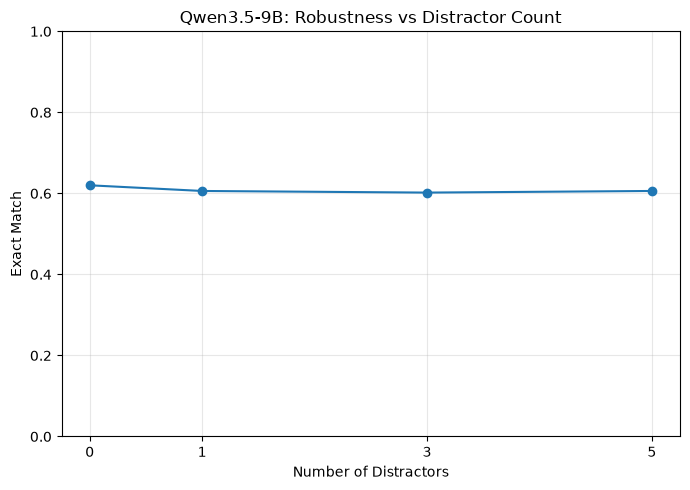

In [30]:
plt.figure(figsize=(7, 5))

x = [0, 1, 3, 5]

y = [
    clean_em,
    float(
        distractor_summary.loc[
            distractor_summary["condition"] == "D1",
            "em"
        ].iloc[0]
    ),
    float(
        distractor_summary.loc[
            distractor_summary["condition"] == "D3",
            "em"
        ].iloc[0]
    ),
    float(
        distractor_summary.loc[
            distractor_summary["condition"] == "D5",
            "em"
        ].iloc[0]
    ),
]

plt.plot(x, y, marker="o")
plt.xlabel("Number of Distractors")
plt.ylabel("Exact Match")
plt.title("Qwen3.5-9B: Robustness vs Distractor Count")
plt.xticks(x)
plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "distractor_em.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

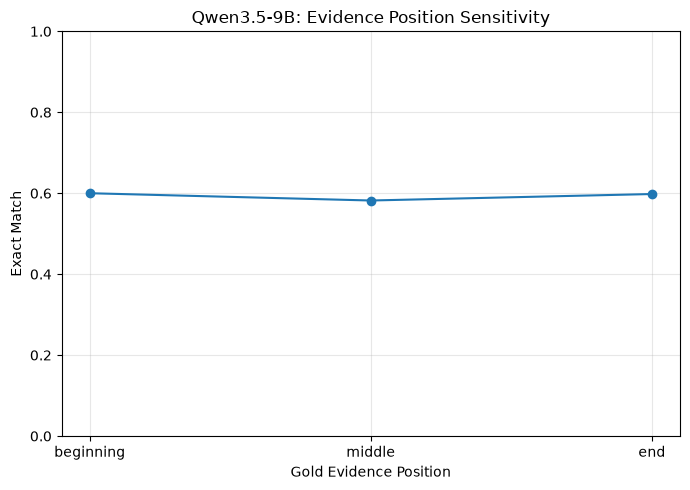

In [31]:
# Position bias
plt.figure(figsize=(7, 5))

plt.plot(
    position_summary["condition"].astype(str),
    position_summary["em"],
    marker="o",
)

plt.xlabel("Gold Evidence Position")
plt.ylabel("Exact Match")
plt.title("Qwen3.5-9B: Evidence Position Sensitivity")
plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "position_em.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

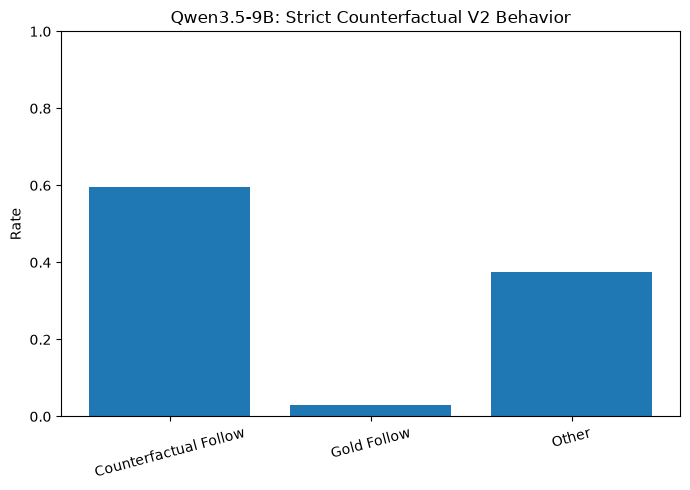

In [32]:
# Counterfactual V2
plt.figure(figsize=(7, 5))

labels = [
    "Counterfactual Follow",
    "Gold Follow",
    "Other",
]

values = [
    CFR,
    GFR,
    OTHER_RATE,
]

plt.bar(
    labels,
    values,
)

plt.ylabel("Rate")
plt.title("Qwen3.5-9B: Strict Counterfactual V2 Behavior")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "counterfactual_v2_behavior.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## 28. Final summary JSON

In [33]:
summary = {
    "model": MODEL_NAME,
    "dtype": "bfloat16",
    "quantized": False,

    "dataset_sizes": {
        "clean": len(clean_eval),
        "distractor": len(distractor_eval),
        "position": len(position_eval),
        "counterfactual_v2": len(cf_eval),
    },

    "clean": {
        "em": float(clean_em),
        "f1": float(clean_f1),
    },

    "distractor": {
        str(row["condition"]): {
            "n": int(row["n"]),
            "em": float(row["em"]),
            "f1": float(row["f1"]),
            "em_drop_vs_clean":
                float(row["em_drop_vs_clean"]),
            "f1_drop_vs_clean":
                float(row["f1_drop_vs_clean"]),
        }
        for _, row
        in distractor_summary.iterrows()
    },

    "position": {
        str(row["condition"]): {
            "n": int(row["n"]),
            "em": float(row["em"]),
            "f1": float(row["f1"]),
            "em_drop_vs_clean":
                float(row["em_drop_vs_clean"]),
            "f1_drop_vs_clean":
                float(row["f1_drop_vs_clean"]),
        }
        for _, row
        in position_summary.iterrows()
    },

    "counterfactual_v2": {
        "n": int(cf_n),

        "counterfactual_follow":
            int(
                cf_counts[
                    "COUNTERFACTUAL_FOLLOW"
                ]
            ),

        "gold_follow":
            int(
                cf_counts[
                    "GOLD_FOLLOW"
                ]
            ),

        "other":
            int(
                cf_counts[
                    "OTHER"
                ]
            ),

        "CFR": float(CFR),
        "GFR": float(GFR),
        "other_rate": float(OTHER_RATE),
    },
}

SUMMARY_FILE = (
    EVAL_DIR
    / "qwen35_9b_rag_stress_summary.json"
)

with SUMMARY_FILE.open(
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        summary,
        f,
        indent=2
    )

print(
    json.dumps(
        summary,
        indent=2
    )
)

print("\nSaved:", SUMMARY_FILE)

{
  "model": "Qwen/Qwen3.5-9B",
  "dtype": "bfloat16",
  "quantized": false,
  "dataset_sizes": {
    "clean": 500,
    "distractor": 1500,
    "position": 1500,
    "counterfactual_v2": 232
  },
  "clean": {
    "em": 0.62,
    "f1": 0.7750989121989124
  },
  "distractor": {
    "D1": {
      "n": 500,
      "em": 0.606,
      "f1": 0.7656958363274152,
      "em_drop_vs_clean": 0.014000000000000012,
      "f1_drop_vs_clean": 0.009403075871497135
    },
    "D3": {
      "n": 500,
      "em": 0.602,
      "f1": 0.7517931401931401,
      "em_drop_vs_clean": 0.018000000000000016,
      "f1_drop_vs_clean": 0.02330577200577222
    },
    "D5": {
      "n": 500,
      "em": 0.606,
      "f1": 0.7574722014827278,
      "em_drop_vs_clean": 0.014000000000000012,
      "f1_drop_vs_clean": 0.0176267107161846
    }
  },
  "position": {
    "beginning": {
      "n": 500,
      "em": 0.6,
      "f1": 0.7469284785390048,
      "em_drop_vs_clean": 0.020000000000000018,
      "f1_drop_vs_clean": 0.028

## 29. Final Drive manifest

In [34]:
print("QWEN3.5-9B EXPERIMENT COMPLETE")
print("=" * 100)

print("\nRaw inference outputs:")
for path in sorted(RESULTS_DIR.glob("*")):
    print("-", path)

print("\nEvaluation outputs:")
for path in sorted(EVAL_DIR.glob("*")):
    if path.is_file():
        print("-", path)

print("\nFigures:")
for path in sorted(FIGURES_DIR.glob("*")):
    print("-", path)

print("\nEverything is saved under:")
print(MODEL_ROOT)

QWEN3.5-9B EXPERIMENT COMPLETE

Raw inference outputs:
- /content/drive/MyDrive/rag_stress/qwen35_9b/outputs/clean_answers.jsonl
- /content/drive/MyDrive/rag_stress/qwen35_9b/outputs/counterfactual_v2_answers.jsonl
- /content/drive/MyDrive/rag_stress/qwen35_9b/outputs/distractor_answers.jsonl
- /content/drive/MyDrive/rag_stress/qwen35_9b/outputs/position_answers.jsonl

Evaluation outputs:
- /content/drive/MyDrive/rag_stress/qwen35_9b/evaluation/clean_evaluated.jsonl
- /content/drive/MyDrive/rag_stress/qwen35_9b/evaluation/counterfactual_v2_by_source.csv
- /content/drive/MyDrive/rag_stress/qwen35_9b/evaluation/counterfactual_v2_by_type.csv
- /content/drive/MyDrive/rag_stress/qwen35_9b/evaluation/counterfactual_v2_evaluated.jsonl
- /content/drive/MyDrive/rag_stress/qwen35_9b/evaluation/counterfactual_v2_summary.csv
- /content/drive/MyDrive/rag_stress/qwen35_9b/evaluation/distractor_evaluated.jsonl
- /content/drive/MyDrive/rag_stress/qwen35_9b/evaluation/distractor_summary.csv
- /content/

# Output structure

After completion, Google Drive will contain:

```text
MyDrive/
└── rag_stress/
    └── qwen35_9b/
        ├── outputs/
        │   ├── clean_answers.jsonl
        │   ├── distractor_answers.jsonl
        │   ├── position_answers.jsonl
        │   └── counterfactual_v2_answers.jsonl
        │
        └── evaluation/
            ├── clean_evaluated.jsonl
            ├── distractor_evaluated.jsonl
            ├── position_evaluated.jsonl
            ├── counterfactual_v2_evaluated.jsonl
            ├── distractor_summary.csv
            ├── position_summary.csv
            ├── counterfactual_v2_summary.csv
            ├── counterfactual_v2_by_type.csv
            ├── counterfactual_v2_by_source.csv
            ├── qwen35_9b_rag_stress_summary.json
            └── figures/
                ├── distractor_em.png
                ├── position_em.png
                └── counterfactual_v2_behavior.png
```

Because inference outputs are appended directly to Drive, an interrupted Colab session can be resumed without rerunning completed examples.
